<div style="text-align: justify;
text-justify: inter-word; font-size: 17px;">

Experiment Setup:

The following rusults correspond to an extreme case of *pure shear-dominant* ABL, where sensible and latent heat are nullified:<br>

Sensible Heat Flux, SHF=0 *$W/m^{2}$*<br>

Latent Heat, LHF = 0 *$W/m^{2}$*<br>

Friction velocity $u_{*}$ was intesified from 0.25 m/s to 0.65 m/s.

The initial wind velocity profiles were given by the relationships: *$u(z) = 6.5 + {2 {z} \over {1000}}$* (m/s)  and  *$v(z) = -8.5 +{{5z} \over {1000}}$* (m/s).

The cloud layer extens from 500 to 795 m and the domain top is set at 1500, with buffer layer applied between 1250-1500 m.
</div>  

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import io
import matplotlib.colors as mcolors
import requests

<div style="text-align: justify;
text-justify: inter-word; font-size: 19px;">
The 128 vertical levels (heights) are written in 'Z0' ASCII file continuously. Values are reshaped into 1D vector.
</div>

In [50]:
url1="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/Z0"
response = requests.get(url1)
response.raise_for_status()
z = response.text.split()
z = np.array(z, dtype=float)
z = z.reshape(128)
#---ABL top after 8 hours retrived from time series---
zi=830
z=z/zi

<div style="text-align: justify;
text-justify: inter-word; font-size: 18px;">
Post-proccessed spatially-averaged verical profiles are written every ~300s. The first simulation hour is considered as spin-up time and are not included in the analysis. The total simulation time was 8 hours; however, only the final time step was used for analysis, assuming fully developed turbulance.  Mean profiles are also written continuously in 'PRO' ASCII files and reshaped in 2D arrays with u,z coordinates.
</div>

In [51]:
url2="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/U_s.pro.0000"
response = requests.get(url2)
response.raise_for_status()
u_raw = response.text.split()

# Filter out the '#' character and Exclude elements at indices 0, 129, 2*129, etc where the time step (sec) is indicated
u_filtered_hash = [item for item in u_raw if item != '#']
u_final_list = [item for i, item in enumerate(u_filtered_hash) if i % 129 != 0]

u = np.array(u_final_list, dtype=float)
u_m = u.reshape(95,128)
U_m=u_m[94,0:128]

<div style="text-align: justify;
text-justify: inter-word; font-size: 18px;">
Reading 3D instataneous velocity fileds with horizontal resolution of 50m.
</div>

In [52]:
url3="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/U_3s.28800"
def read_fortran_file(filename, nx, ny, nz):
    response = requests.get(filename)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    data = response.text.split()
    data = np.array(data, dtype=float)
    field = data.reshape((nz, ny, nx))
    field=np.transpose(field,(2,1,0))
    return field
u=read_fortran_file(url3,97,97,129)
u=u[:,:,0:128]
x=np.arange(0,4850,50)
y=np.arange(0,4850,50)

<div style="text-align: justify;
text-justify: inter-word; font-size: 20px;">

Turbulance calculation from 3D instantaneous fields where $\tilde{u}$ is spatially-averaged quantity: *$u'=u-\tilde{u}$* .
</div>

In [53]:
u3d=u-U_m[np.newaxis,np.newaxis,:]

<div style="text-align: justify;
text-justify: inter-word; font-size: 20px;">
Data visualization
</div>

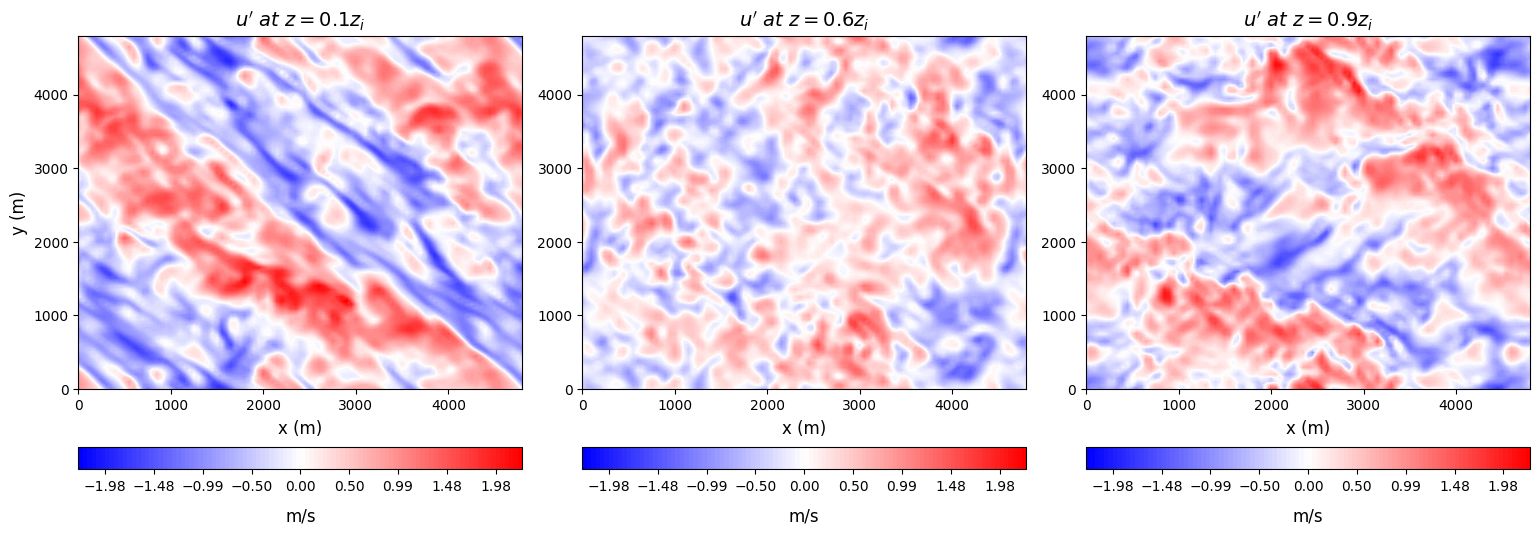

In [54]:
u_slice=[u3d[:,:,14],u3d[:,:,40],u3d[:,:,70]]
vmin=-2.25
vmax=2.25
bounds=np.linspace(vmin,vmax,101)
for i in range(len(bounds)):
    bounds[i]=round(bounds[i],2)
cmap=plt.get_cmap("bwr",100)
norm=mcolors.BoundaryNorm(boundaries=bounds,ncolors=100)
titles=["$u'$ $at$ $z=0.1z_{i}$","$u'$ $at$ $z=0.6z_{i}$","$u'$ $at$ $z=0.9z_{i}$"]
i=0
fig,axs=plt.subplots(1,3,figsize=(15.5,5.5))
for title in titles:
  cf=axs[i].contourf(x,y,u_slice[i],levels=bounds,cmap=cmap)
  cbar=fig.colorbar(cf,ax=axs[i],orientation='horizontal',pad=0.12)
  cbar.set_label("m/s",fontsize=12,labelpad=10,rotation=0)
  axs[i].set_xlabel("x (m)",fontsize=12,labelpad=5)
  axs[i].set_title(title,fontsize=14)
  i+=1
axs[0].set_ylabel("y (m)",fontsize=12)
plt.tight_layout()
plt.show()

### Results and Discussion

<div style="text-align: justify;
text-justify: inter-word; font-size: 19px;">

Coherent elongated “streaks” of velocity appeared, consisting of regions with positive and negative fluctuations of the velocity field in both the lower and upper levels of the ABL. These distinct streaks have also been observed in all wall-bounded shear turbulent flows (Kline et al., 1967) and in other LES simulations (Moeng & Sullivan, 1994; Khanna & Brasseur, 1998). They are driven by streamwise counter-rotating vortices: streaks of negative velocity fluctuations are associated with the upward-moving flow of vortices, while streaks of positive fluctuations correspond to the downward-moving flow.


</div>

![My image](https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/main/data/image.png)

<div style="text-align: justify;
text-justify: inter-word; font-size: 19px;">
In shear flow, as shown in the figure above, slower fluid moving upward induces negative velocity fluctuations, meaning that it slows down the mean flow. Conversely, faster fluid moving downward induces positive velocity fluctuations, which accelerate the mean flow. Since counter-rotating vortices extend throughout the domain (as small rolls), the upward- and downward-moving fluid has equal extent, resulting in the formation of “streak” structures in the fluctuating velocity field. Above the surface layer, the streaks have a spanwise width larger than the boundary layer thickness. In the mid-ABL (below the cloud layer), the streaks disappear and only random, small-scale velocity fluctuations are observed. However, close to the ABL top (within the cloud layer), wider streaks with shorter streamwise length scales reappear. The reason for this mid-level disappearance is that the shear vanishes and the ABL becomes well mixed.
</div>

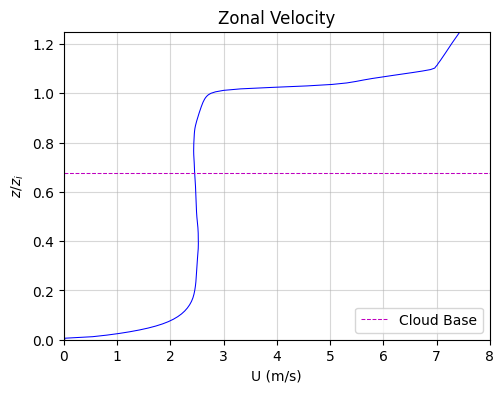

In [55]:
# Cloud base after 8 hours of simulation
c_base=560/zi

fig,ax=plt.subplots(figsize=(5.5,4))
ax.plot(U_m,z,linewidth=0.75,color="b")
ax.set_ylabel("$z/z_i$")
ax.set_ylim([0,1.25])
ax.set_xlim([0,8])
ax.grid(alpha=0.5)
ax.set_title("Zonal Velocity")
ax.set_xlabel("U (m/s)")
ax.axhline(y=c_base,linewidth=0.75,color="m",label="Cloud Base",linestyle="--")
ax.legend(loc="lower right")
plt.show()

<div style="text-align: justify;
text-justify: inter-word; font-size: 18px;">
As shown in the figure above, shear is present within the surface layer and at the cloud top, between 750 and 850 m. The stronger the shear, the more elongated the streaks (Lee et al., 1990); this explains why, in this simulation, streak structures are more intense and elongated near the surface. Finally, it is worth noting that this case does not represent a purely shear-dominated ABL, even though the SHF and LHF have been set to zero, as illustrated in the TKE buoyancy production plot, with additional supporting plots of TKE production and turbulent fluxes provided in a separate repository. The presence of the cloud layer produces the largest values of buoyancy production due to radiative cooling at the cloud top, which generates downdrafts. These downdrafts weaken as they approach the surface, leading to the formation of compensating updrafts
</div>